# Inference Demo

In [1]:
# move to project root
import pyrootutils
path = pyrootutils.setup_root(
    search_from=".", 
    indicator=".git", 
    cwd=True
)
print(f"Project root: {path}")

from huggingface_hub import snapshot_download, hf_hub_download
from CTPEvaluator import CTPEvaluator
from IPython.display import JSON, display
import glob

Project root: /home/ximeng/Documents/CTP
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Download Dataset

In [2]:
# nuscenes
snapshot_download(
    repo_id="Ximeng0831/CTP-Dataset", 
    repo_type="dataset",
    local_dir="dataset",
    allow_patterns="nuscenes_triplets/*"
)
# kitti, Named with '_train' suffix as it was generated from the KITTI training set
snapshot_download(
    repo_id="Ximeng0831/CTP-Dataset", 
    repo_type="dataset",
    local_dir="dataset",
    allow_patterns="kitti_triplets/*"
)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

'/home/ximeng/Documents/CTP/dataset'

## Download the Model

In [3]:
# Available: ["192_l2_tensor_all", "192_l2_tensor_nm_all", "192_cos_tensor_all", "192_cos_matrix_all", "192_l2_tensor_pc", "192_cos_matrix_pc", "192_cos_matrix_IP_pc"]
# 192_l2_tensor_all is the default config
config_name = "192_l2_tensor_all"

In [4]:
checkpoint_path = hf_hub_download(
    repo_id="Ximeng0831/CTP",
    subfolder=config_name,
    filename="ckpt_epoch9.pt",
    local_dir="checkpoints"
)

##

## Load the Evaluator

In [16]:
config_path = f"configs/{config_name}.yaml"
eval_path = "dataset/nuscenes_triplets/nuscenes_triplet_val.jsonl"
loss_fn = "cosine_matrix_loss_eval"
tau = 0.5

evaluator = CTPEvaluator(
    config_path=config_path, 
    eval_path=eval_path, 
    loss_fn=loss_fn, 
    tau=tau
)

[Info] Detected dataset type: nuscenes
[Info] Evaluation parameters: loss_fn=cosine_matrix_loss_eval, tau=0.5
[Info] Loading checkpoint: checkpoints/192_l2_tensor_all/ckpt_epoch9.pt
[INFO] LiDAR TAR detected: nuscenes_lidar.tar
[INFO] Image TAR detected: nuscenes_image.tar


## Zero-shot Classification

In [17]:
res, acc = evaluator.run_evaluation()

Eval nuscenes: 100%|██████████| 265/265 [02:34<00:00,  1.71it/s]


In [18]:
display(JSON(res))
print(f"Accuracy: {acc:.4f}")

<IPython.core.display.JSON object>

Accuracy: 0.6949


## Visualization

 - checkpoints/192_l2_tensor_all/ckpt_epoch9.pt

[Info] No 'before_ckpt' provided. Using random initial state.


Extracting car: 100%|██████████| 200/200 [00:11<00:00, 17.65it/s]


[Info] Loading checkpoint: checkpoints/192_l2_tensor_all/ckpt_epoch9.pt


Extracting car: 100%|██████████| 200/200 [00:11<00:00, 17.61it/s]
/home/ximeng/anaconda3/envs/ctp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Success] UMAP plot saved to: results/alignment/192_l2_tensor_all_umap_car_20260330_2308.png


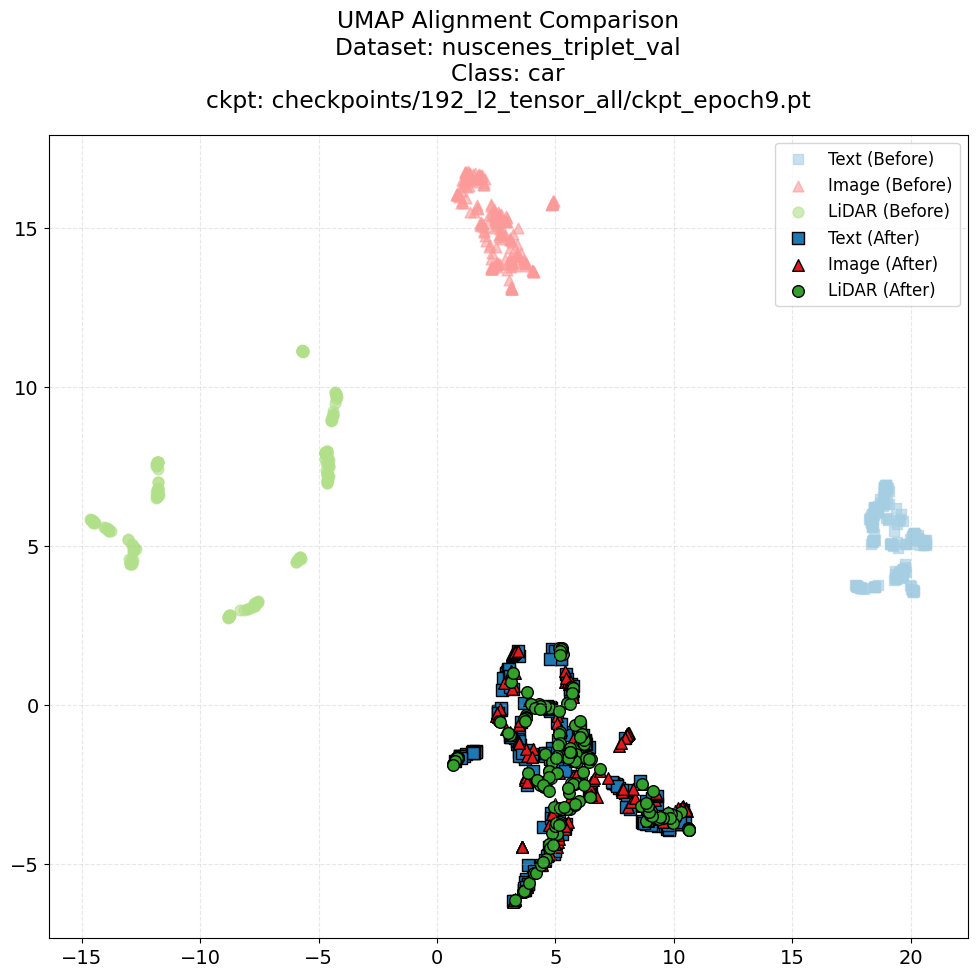

In [19]:
label = "car"
# Find the latest checkpoint in the directory
after_ckpt_path = f"checkpoints/{config_name}/ckpt_*.pt"
ckpt_files = glob.glob(after_ckpt_path)
ckpt_files.sort() 
if ckpt_files:
    for f in ckpt_files:
        print(f" - {f}")
    last_ckpt = ckpt_files[-1]

evaluator.plot_embedding_comparison(
    target_label=label,
    after_ckpt_path=last_ckpt
)